# Titanic Dataset Analysis, Modeling, and Deployment
Covers Part 1–4: EDA, preprocessing, modeling, saving best model.

_Charts use matplotlib only (one figure per chart)._

In [22]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import joblib
plt.rcParams['figure.figsize'] = (7,5)


## Part 1 — Load & Inspect

In [23]:
DATA_PATHS = ['train.csv', os.path.join('data','train.csv'), os.path.join('..','data','train.csv')]
csv_path = next((p for p in DATA_PATHS if os.path.exists(p)), None)
assert csv_path is not None, "Download Kaggle Titanic `train.csv` and place it next to this notebook or in ./data/"
print("Using:", csv_path)
df = pd.read_csv(csv_path)
df.head()

Using: data\train.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [24]:
print("\nInfo:"); print(df.info())
print("\nMissing values:"); print(df.isna().sum())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embark

### Preprocessing plan
- Numeric: median impute + scale
- Categorical: most_frequent impute + one-hot
- Features: Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
- Target: Survived

In [25]:
target = 'Survived'
features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']
X, y = df[features].copy(), df[target].copy()

num = ['Age','SibSp','Parch','Fare']
cat = ['Pclass','Sex','Embarked']

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                ('scaler', StandardScaler())])
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                    ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', numeric_transformer, num),
                                  ('cat', categorical_transformer, cat)])

## Part 2 — EDA (selected visuals)

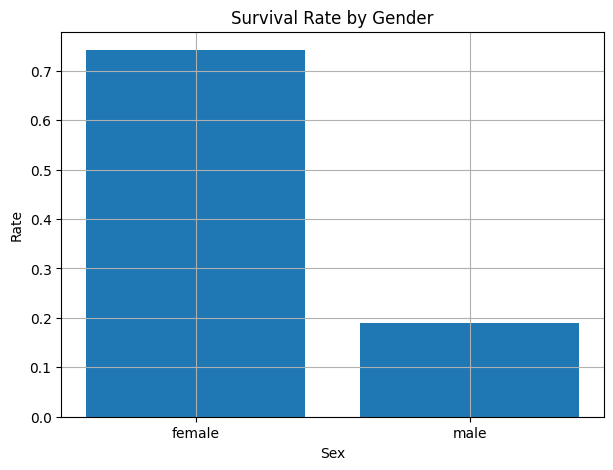

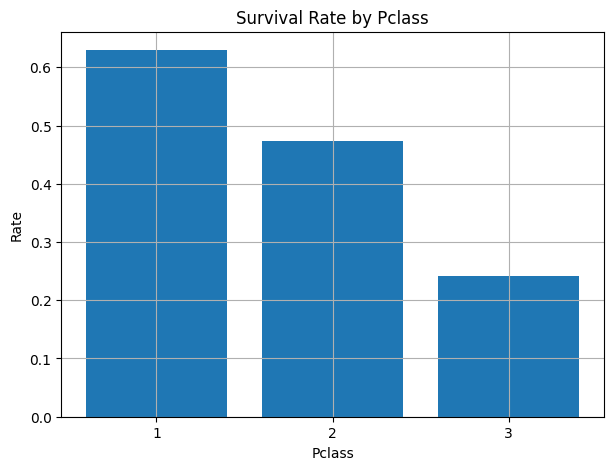

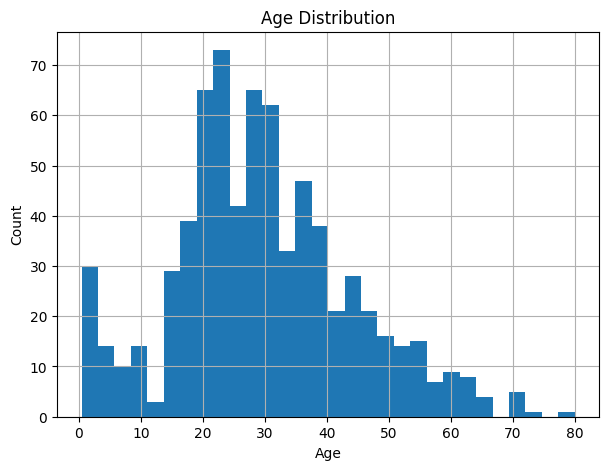

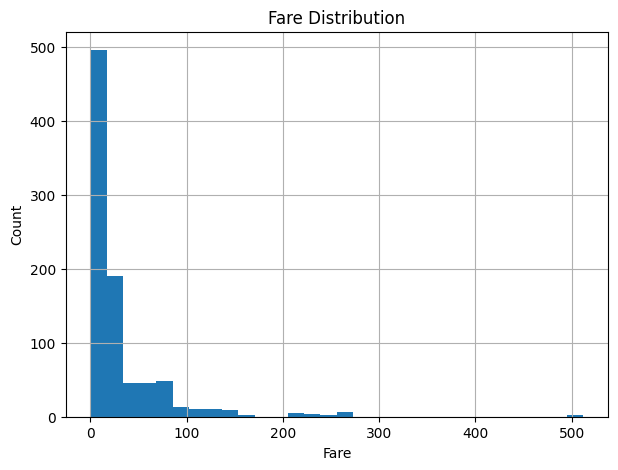

C:\Users\HP\AppData\Local\Temp\ipykernel_40800\3518827177.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.figure(); plt.boxplot([df[df['Survived']==0]['Fare'].dropna(), df[df['Survived']==1]['Fare'].dropna()], labels=['Not Survived','Survived']); plt.title('Fare by Survival'); plt.ylabel('Fare'); plt.grid(True); plt.show()


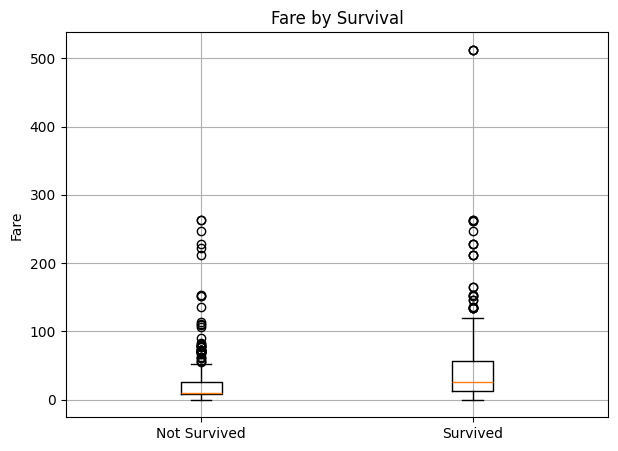

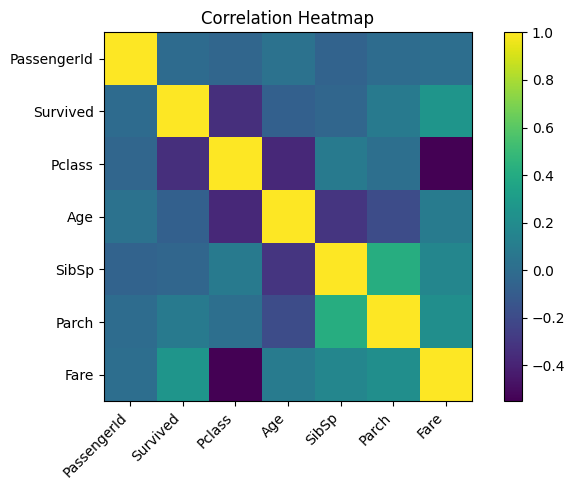

In [26]:
# Survival by Sex
surv_by_sex = df.groupby('Sex')['Survived'].mean().sort_values(ascending=False)
plt.figure(); plt.bar(surv_by_sex.index.astype(str), surv_by_sex.values); plt.title('Survival Rate by Gender'); plt.xlabel('Sex'); plt.ylabel('Rate'); plt.grid(True); plt.show()

# Survival by Pclass
surv_by_class = df.groupby('Pclass')['Survived'].mean().sort_index()
plt.figure(); plt.bar(surv_by_class.index.astype(str), surv_by_class.values); plt.title('Survival Rate by Pclass'); plt.xlabel('Pclass'); plt.ylabel('Rate'); plt.grid(True); plt.show()

# Age distribution
plt.figure(); df['Age'].hist(bins=30); plt.title('Age Distribution'); plt.xlabel('Age'); plt.ylabel('Count'); plt.grid(True); plt.show()

# Fare distribution
plt.figure(); df['Fare'].hist(bins=30); plt.title('Fare Distribution'); plt.xlabel('Fare'); plt.ylabel('Count'); plt.grid(True); plt.show()

# Boxplot: Fare by Survival
plt.figure(); plt.boxplot([df[df['Survived']==0]['Fare'].dropna(), df[df['Survived']==1]['Fare'].dropna()], labels=['Not Survived','Survived']); plt.title('Fare by Survival'); plt.ylabel('Fare'); plt.grid(True); plt.show()

# Heatmap (numeric)
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
corr = df[numeric_cols].corr()
plt.figure(); plt.imshow(corr, interpolation='nearest'); plt.title('Correlation Heatmap'); plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right'); plt.yticks(range(len(numeric_cols)), numeric_cols); plt.colorbar(); plt.tight_layout(); plt.show()

## Part 3 — Modeling


=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



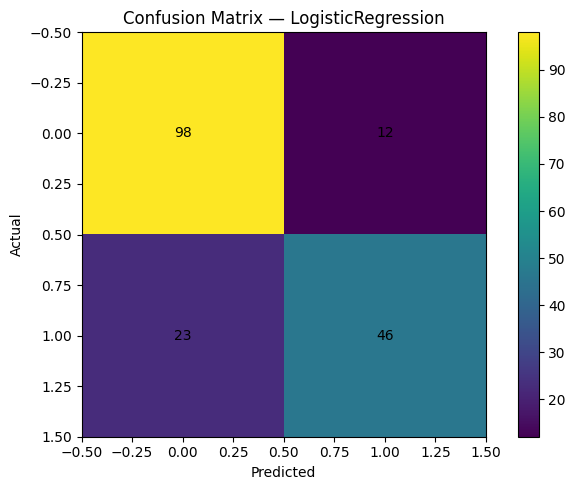

<Figure size 700x500 with 0 Axes>

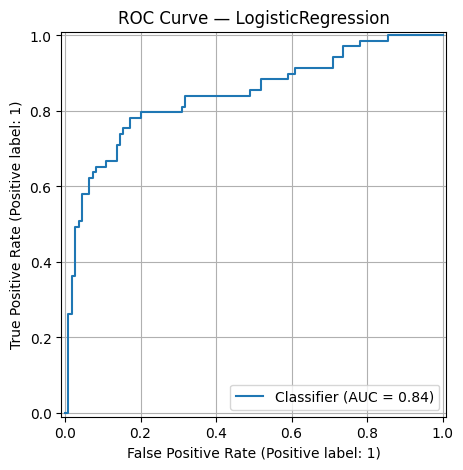


=== KNN (k=7) ===
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       110
           1       0.78      0.65      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



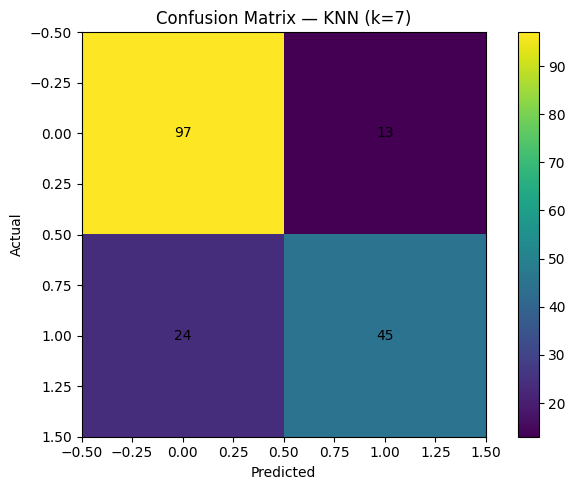

<Figure size 700x500 with 0 Axes>

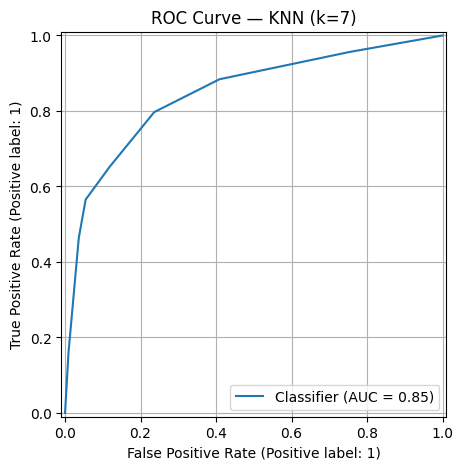


=== SVC (RBF) ===
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       110
           1       0.82      0.67      0.74        69

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



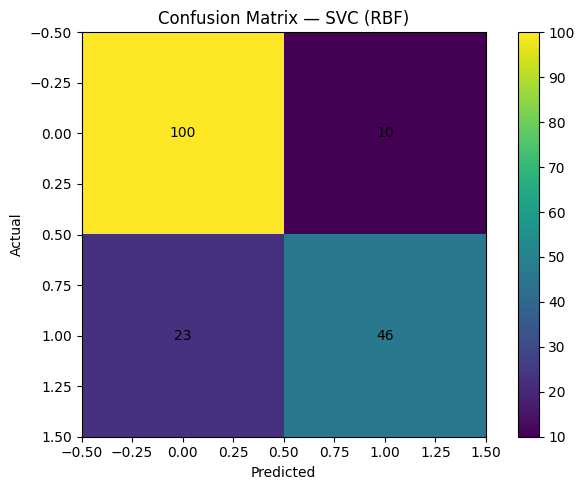

<Figure size 700x500 with 0 Axes>

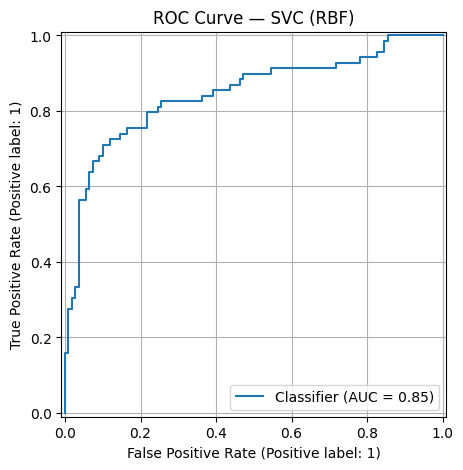

,Model,Accuracy,Precision,Recall,F1,ROC AUC
2,SVC (RBF),0.815642,0.821429,0.666667,0.736000,0.846245
0,LogisticRegression,0.804469,0.793103,0.666667,0.724409,0.842688
1,KNN (k=7),0.793296,0.775862,0.652174,0.708661,0.846179


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'LogisticRegression': Pipeline([('preprocess', preprocessor), ('model', LogisticRegression(max_iter=1000))]),
    'KNN (k=7)': Pipeline([('preprocess', preprocessor), ('model', KNeighborsClassifier(n_neighbors=7))]),
    'SVC (RBF)': Pipeline([('preprocess', preprocessor), ('model', SVC(probability=True))])
}

rows = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    try:
        y_score = pipe.predict_proba(X_test)[:,1]
    except Exception:
        try:
            y_score = pipe.decision_function(X_test)
        except Exception:
            y_score = None
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_score) if y_score is not None else float('nan')
    rows.append([name, acc, prec, rec, f1, auc])

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))

    from sklearn.metrics import ConfusionMatrixDisplay
    from sklearn.metrics import RocCurveDisplay as RCD
    # Confusion matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(); plt.imshow(cm); plt.title(f'Confusion Matrix — {name}'); plt.xlabel('Predicted'); plt.ylabel('Actual')
    for (i,j), val in np.ndenumerate(cm):
        plt.text(j, i, f'{val}', ha='center', va='center')
    plt.colorbar(); plt.tight_layout(); plt.show()

    # ROC
    if y_score is not None:
        plt.figure(); RCD.from_predictions(y_test, y_score); plt.title(f'ROC Curve — {name}'); plt.grid(True); plt.show()

metrics_df = pd.DataFrame(rows, columns=['Model','Accuracy','Precision','Recall','F1','ROC AUC']).sort_values('F1', ascending=False)
metrics_df

## Part 4 — Save Best Model

In [ ]:
best_name = metrics_df.iloc[0]['Model']
best_model = models[best_name]
best_model.fit(X, y)  # refit on all data

joblib.dump(best_model, 'model.pkl')
print('Saved best model to model.pkl (pipeline with preprocessing + estimator).')

Saved best model to model.pkl (pipeline with preprocessing + estimator).


In [30]:
metrics_df = pd.DataFrame(rows, columns=['Model','Accuracy','Precision','Recall','F1','ROC AUC']).sort_values('F1', ascending=False)
metrics_df


,Model,Accuracy,Precision,Recall,F1,ROC AUC
2,SVC (RBF),0.815642,0.821429,0.666667,0.736000,0.846245
0,LogisticRegression,0.804469,0.793103,0.666667,0.724409,0.842688
1,KNN (k=7),0.793296,0.775862,0.652174,0.708661,0.846179


In [ ]:
import os
import pandas as pd


DATA_PATHS = ['test.csv', os.path.join('data','test.csv'), os.path.join('..','data','test.csv')]
csv_path = next((p for p in DATA_PATHS if os.path.exists(p)), None)
assert csv_path is not None, " Please download Kaggle Titanic `test.csv` and place it next to this notebook or in ./data/"

print("Using:", csv_path)
titanic_test_data = pd.read_csv(csv_path)




Using: data\test.csv


In [ ]:
model = joblib.load("model.pkl")

features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']

predictions = model.predict(titanic_test_data[features])


In [34]:
final_df = pd.DataFrame({
    "PassengerId": titanic_test_data["PassengerId"],
    "Survived": predictions
})

final_df.to_csv("Finalresult.csv", index=False)

print("✅ Finalresult.csv created successfully!")
print(final_df.head(10))  # preview first 10 rows


✅ Finalresult.csv created successfully!
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         0
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0
